In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from pathlib import Path
import sys
import joblib

sys.path.insert(0, str(Path("..").resolve()))
from src.features import (
    MODULE_TEMP_FEATURES,
    make_ac_power_features,
    make_module_temperature_features,
)
from src.forecast import generate_rolling_forecasts
from src.models import create_module_temperature_model
from src.predict import predict_ac_power
from src.evaluation import (
    compare_models,
    evaluate_by_horizon,
    plot_forecast_variable_comparisons,
    plot_weekly_ac_power_comparison,
)

generate variables as paths

In [2]:
models_dir = Path("../models")
data_dir = Path("../data")

now load models and data using paths

In [4]:
lr_loaded = joblib.load(models_dir / "linear_regression.joblib")
rf_loaded = joblib.load(models_dir / "random_forest_regressor.joblib")
hgb_loaded = joblib.load(models_dir / "hist_gradient_boosting_regressor.joblib")
xgb_loaded = joblib.load(models_dir / "xgboost_regressor.joblib")
scaler_loaded = joblib.load(models_dir / "scaler.joblib")

nn_loaded = tf.keras.models.load_model(
    models_dir / "neural_network.keras"
)

df = pd.read_parquet(data_dir / 'processed/solar_clean.parquet')

take only records for 2023

In [6]:
df_23 = df[
    df['timestamp'] >= '2023-01-01'
].copy()

df_23 = df_23[
    [
        "timestamp",
        "irradiance",
        "ambient_temp",
        "module_temp_mean",
        "ac_power"
    ]
]

i will create now a forecast for variables irradiance and ambient temperature for next 7 days, the idea is to generate a dataset based on real data we have for january and february of 2023 that show a forecast simulation of irradiance and ambient temperature every 7 days

this way we can simulate what happen on our prediction of ac power if we had only a forecast once every week, adding stocastic variation with an increasing indetermination in forecast of the last days of the week, that means that every day of the week is more complicated to calculate with accuracy irradiance and temperature (an aproximation to real life forecasting) but without random noise

i will build a function that give as a forecast for the next 7 days, as we have records for every minute, is better to do the calculation for every 30 minutes and then do an interpolation between them to make an easier forecast model

Rolling forecasts are generated after the module-temperature model is fitted, using `src.forecast`.

now, using the forecasting for irradiance and ambient temperature, let's use them to forecast the mean module temperature that we need for using the models we trained

In [51]:
# ==================================================
# 1. Prepare historical module-temperature data
# ==================================================

module_features = list(MODULE_TEMP_FEATURES)
module_target = "module_temp_mean"

df_module = make_module_temperature_features(df)
df_module[module_target] = df[module_target]
df_module["timestamp"] = pd.to_datetime(df["timestamp"])
df_module = (
    df_module.loc[df_module["timestamp"] < "2023-01-01"]
    .dropna()
    .sort_values("timestamp")
    .copy()
)


# ==================================================
# 2. Temporal train/validation split
# ==================================================

split_idx = int(len(df_module) * 0.80)
train_module = df_module.iloc[:split_idx].copy()
val_module = df_module.iloc[split_idx:].copy()

X_module_train = train_module[module_features]
y_module_train = train_module[module_target]
X_module_val = val_module[module_features]
y_module_val = val_module[module_target]


# ==================================================
# 3. Train and evaluate module-temperature model
# ==================================================

module_model = create_module_temperature_model()
module_model.fit(X_module_train, y_module_train)

module_val_pred = module_model.predict(X_module_val)
module_residuals = y_module_val.to_numpy() - module_val_pred

val_residuals = val_module[["timestamp", "irradiance"]].copy()
val_residuals["residual"] = module_residuals

night_threshold = 50  # W/m²
day_residuals = val_residuals.loc[
    val_residuals["irradiance"] >= night_threshold,
    "residual",
]
night_residuals = val_residuals.loc[
    val_residuals["irradiance"] < night_threshold,
    "residual",
]

day_residual_std = day_residuals.std()
night_residual_std = night_residuals.std()
day_residual_mean = day_residuals.mean()
night_residual_mean = night_residuals.mean()

print(f"Day residual std:   {day_residual_std:.3f} °C")
print(f"Night residual std: {night_residual_std:.3f} °C")
print(f"Day residual mean:  {day_residual_mean:.3f} °C")
print(f"Night residual mean: {night_residual_mean:.3f} °C")


# ==================================================
# 4. Fit final model and generate rolling forecasts
# ==================================================

X_module_all = df_module[module_features]
y_module_all = df_module[module_target]
module_model.fit(X_module_all, y_module_all)

df_forecast = generate_rolling_forecasts(
    df_23,
    module_temperature_model=module_model,
    day_residual_std=float(day_residual_std),
    night_residual_std=float(night_residual_std),
    night_residual_mean=float(night_residual_mean),
    horizon_days=7,
    random_state=42,
)

if df_forecast.empty:
    raise ValueError("No rolling forecasts could be generated from df_23.")

print(f"Forecast rows: {len(df_forecast):,}")
print(
    f"Forecast period: {df_forecast['timestamp'].min()} "
    f"to {df_forecast['timestamp'].max()}"
)
print(f"Duplicated timestamps: {df_forecast['timestamp'].duplicated().sum()}")


df_forecast[
    [
        "timestamp",
        "forecast_date",
        "horizon_hours",
        "irradiance_forecast",
        "ambient_temp_forecast",
        "module_temp_mean_base",
        "module_temp_error",
        "module_temp_mean_forecast",
        "module_temp_mean",
    ]
].head()

Day residual std:   3.807 °C
Night residual std: 1.533 °C
Day residual mean:  0.296 °C
Night residual mean: 0.228 °C
Forecast rows: 77,878
Forecast period: 2023-01-01 00:01:00 to 2023-03-01 06:59:00
Duplicated timestamps: 0


,timestamp,forecast_date,horizon_hours,irradiance_forecast,ambient_temp_forecast,module_temp_mean_base,module_temp_error,module_temp_mean_forecast,module_temp_mean
0,2023-01-01 00:01:00,2023-01-01,0.016667,0.0,1.871163,2.099495,0.511762,2.611257,3.300333
1,2023-01-01 00:02:00,2023-01-01,0.033333,0.0,1.871240,2.099572,0.509352,2.608924,3.288933
2,2023-01-01 00:03:00,2023-01-01,0.050000,0.0,1.871317,2.099648,0.506943,2.606591,3.260667
3,2023-01-01 00:04:00,2023-01-01,0.066667,0.0,1.871394,2.099725,0.504533,2.604258,3.254667
4,2023-01-01 00:05:00,2023-01-01,0.083333,0.0,1.871470,2.099802,0.502124,2.601926,3.185467


no let's check quickly if our forecast of module temperature follows the real temperature

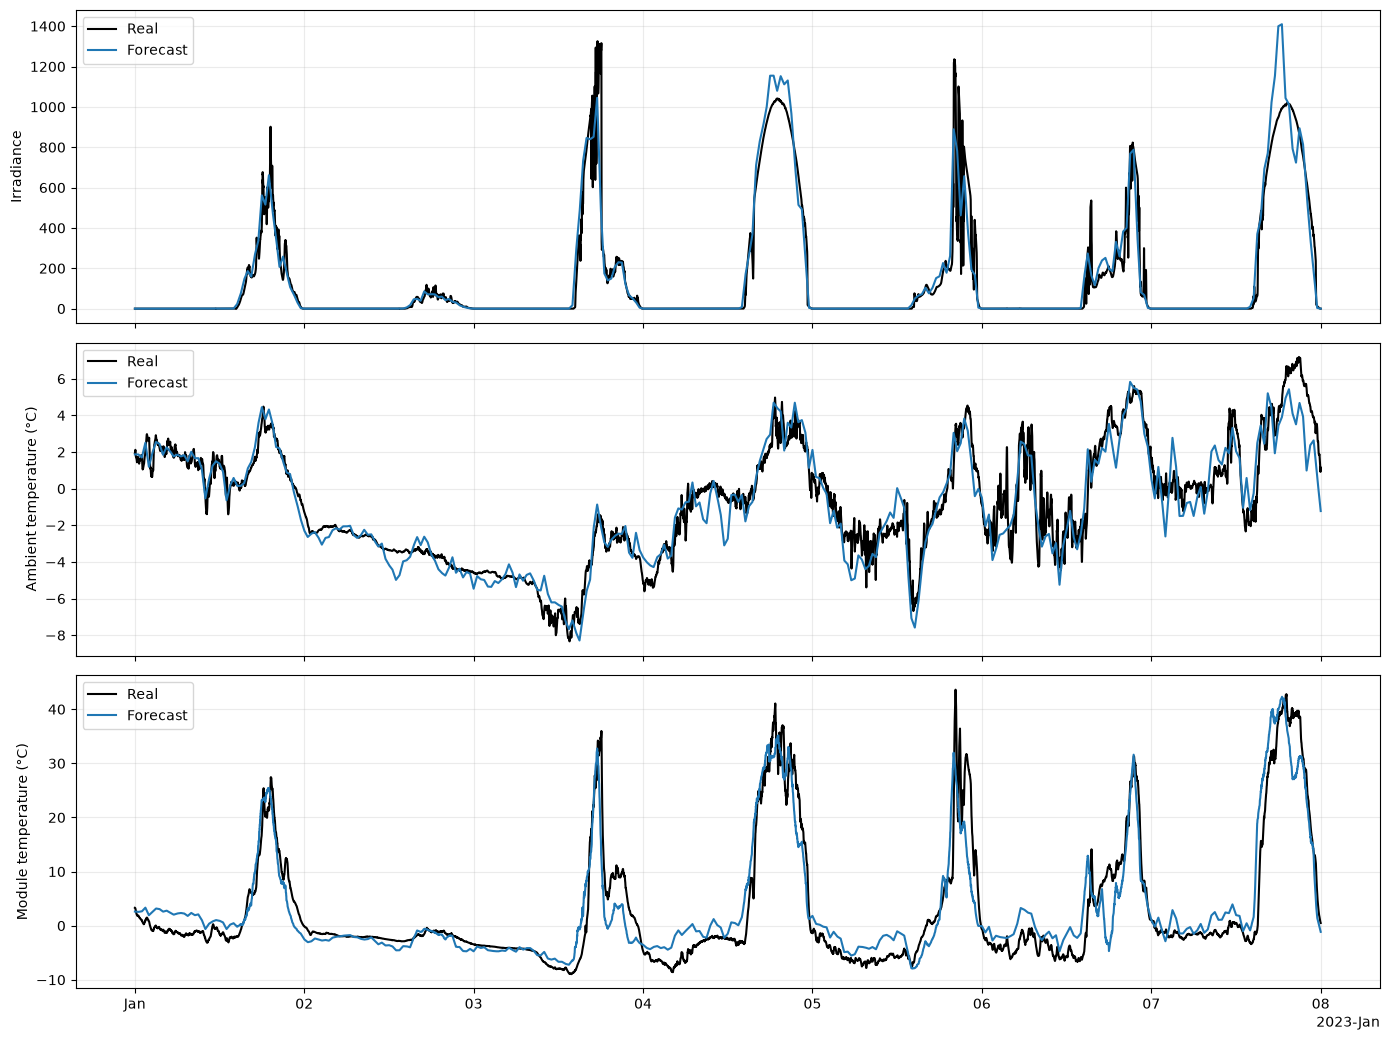

In [62]:
sample = df_forecast[
    df_forecast["forecast_date"]
    == df_forecast["forecast_date"].min()
]

variable_fig, variable_axes = plot_forecast_variable_comparisons(
    sample,
    variable_columns={
        "Irradiance": ("irradiance", "irradiance_forecast"),
        "Ambient temperature (°C)": (
            "ambient_temp",
            "ambient_temp_forecast",
        ),
        "Module temperature (°C)": (
            "module_temp_mean",
            "module_temp_mean_forecast",
        ),
    },
)
plt.show()

In [58]:
# ==================================================
# 1. Prepare forecast features
# ==================================================

X_forecast = make_ac_power_features(
    df_forecast,
    irradiance_col="irradiance_forecast",
    ambient_temp_col="ambient_temp_forecast",
    module_temp_col="module_temp_mean_forecast"
)

expected_features = list(scaler_loaded.feature_names_in_)
if list(X_forecast.columns) != expected_features:
    raise ValueError("Forecast features do not match the saved model schema.")

# Only the neural network was trained with scaled features.
X_forecast_scaled = scaler_loaded.transform(X_forecast)


# ==================================================
# 2. Generate AC power predictions
# ==================================================

ac_power_models = {
    "Linear Regression": lr_loaded,
    "Random Forest": rf_loaded,
    "HistGradientBoosting": hgb_loaded,
    "XGBoost": xgb_loaded,
    "Neural Network": nn_loaded,
}
predictions = predict_ac_power(
    ac_power_models,
    X_forecast,
    X_nn=X_forecast_scaled,
)

for model_name, pred in predictions.items():
    df_forecast[f"ac_power_{model_name}"] = pred


# ==================================================
# 3. Calculate and display scores
# ==================================================

y_true = df_forecast["ac_power"].to_numpy()
scores_df = compare_models(y_true, predictions)

scores_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4,
})

,Model,MAE,MSE,RMSE,R²
0,Random Forest,34.85,6891.16,83.01,0.9106
1,HistGradientBoosting,34.93,6566.51,81.03,0.9148
2,Neural Network,35.06,6180.77,78.62,0.9198
3,XGBoost,36.03,7035.35,83.88,0.9088
4,Linear Regression,51.21,10732.10,103.60,0.8608


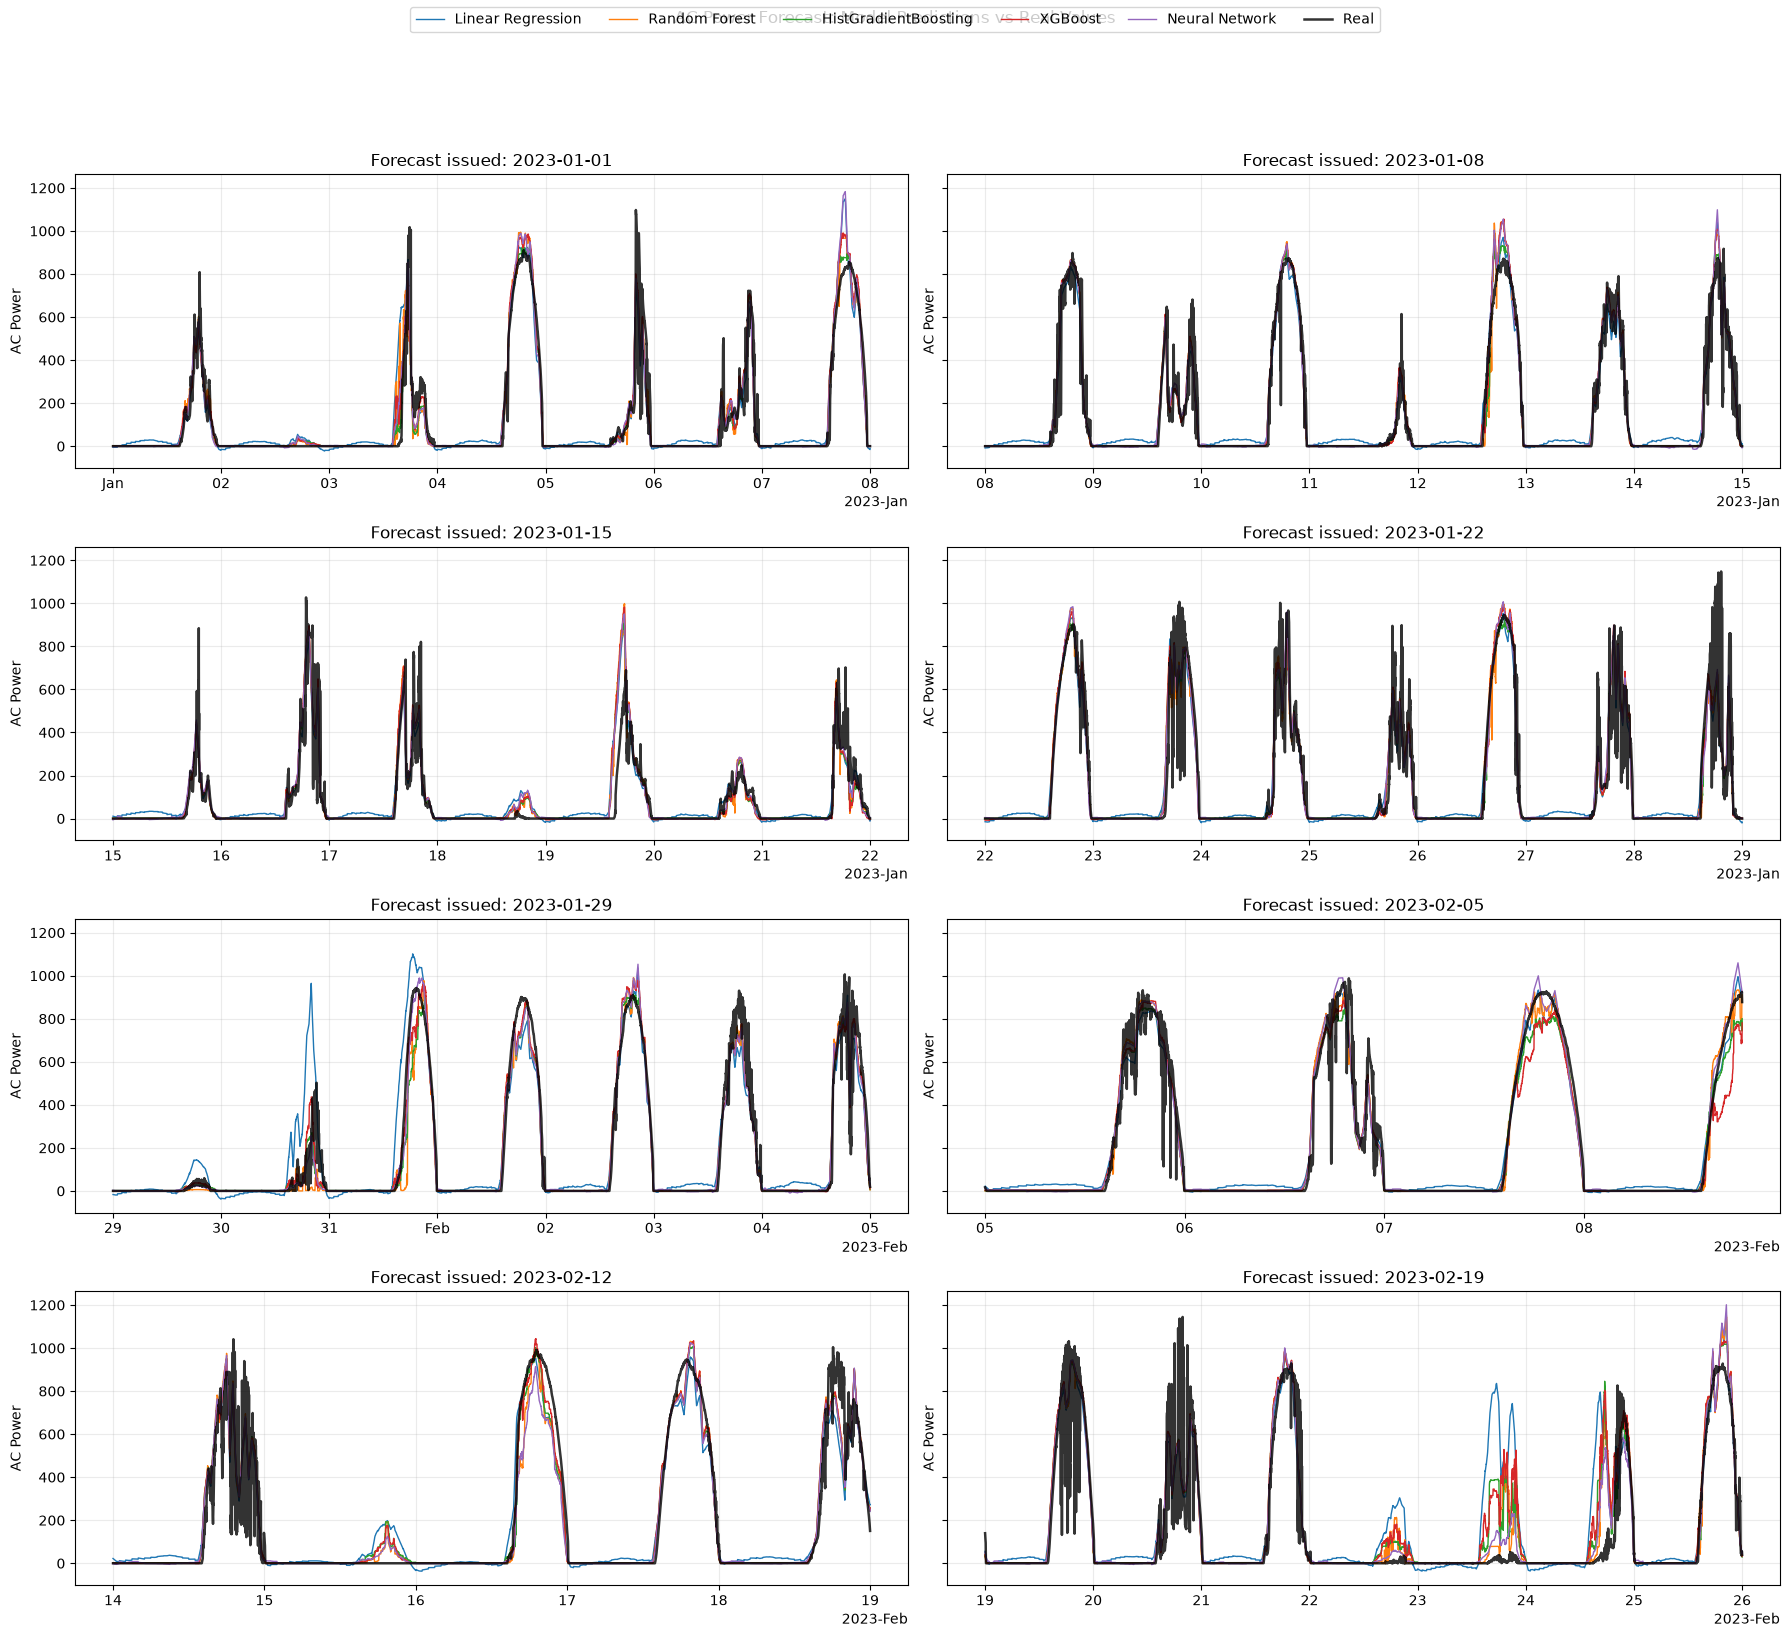

In [61]:
prediction_columns = {
    model_name: f"ac_power_{model_name}"
    for model_name in predictions
}

weekly_fig, weekly_axes = plot_weekly_ac_power_comparison(
    df_forecast,
    prediction_columns=prediction_columns,
    max_weeks=8,
)
plt.show()

In [59]:
# ==================================================
# 1. Select real 2023 data
# ==================================================

df_real_23 = df[
    (df["timestamp"] >= "2023-01-01") &
    (df["timestamp"] < "2024-01-01")
][
    [
        "timestamp",
        "irradiance",
        "ambient_temp",
        "module_temp_mean",
        "ac_power"
    ]
].copy()


# ==================================================
# 2. Prepare features and target
# ==================================================

X_real_23 = make_ac_power_features(df_real_23)
y_real_23 = df_real_23["ac_power"]

expected_features = list(scaler_loaded.feature_names_in_)
if list(X_real_23.columns) != expected_features:
    raise ValueError("Real-data features do not match the saved model schema.")

# Only the neural network was trained with scaled features.
X_real_23_scaled = scaler_loaded.transform(X_real_23)


# ==================================================
# 3. Generate predictions
# ==================================================

ac_power_models = {
    "Linear Regression": lr_loaded,
    "Random Forest": rf_loaded,
    "HistGradientBoosting": hgb_loaded,
    "XGBoost": xgb_loaded,
    "Neural Network": nn_loaded,
}
real_predictions = predict_ac_power(
    ac_power_models,
    X_real_23,
    X_nn=X_real_23_scaled,
)


# ==================================================
# 4. Calculate and display scores
# ==================================================

scores_real_df = compare_models(y_real_23, real_predictions)
scores_real_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4,
})

,Model,MAE,MSE,RMSE,R²
0,Random Forest,9.88,976.25,31.24,0.9873
1,Neural Network,11.59,808.42,28.43,0.9895
2,HistGradientBoosting,12.07,1299.59,36.05,0.9831
3,XGBoost,12.82,1475.05,38.41,0.9809
4,Linear Regression,25.69,4825.02,69.46,0.9374


comparing

In [60]:
metric_columns = ["Model", "MAE", "MSE", "RMSE", "R²"]

print("Scores using predicted variables (forecasting):")
display(scores_df[metric_columns].round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4,
}))

print("Scores using real variables (nowcasting):")
display(scores_real_df[metric_columns].round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4,
}))

horizon_prediction_columns = {
    model_name: f"ac_power_{model_name}"
    for model_name in predictions
}
horizon_scores_df = evaluate_by_horizon(
    df_forecast,
    actual_col="ac_power",
    prediction_columns=horizon_prediction_columns,
)

print("Forecast scores by horizon:")
display(horizon_scores_df.round({
    "MAE": 2,
    "MSE": 2,
    "RMSE": 2,
    "R²": 4,
}))

Scores using predicted variables (forecasting):


,Model,MAE,MSE,RMSE,R²
0,Random Forest,34.85,6891.16,83.01,0.9106
1,HistGradientBoosting,34.93,6566.51,81.03,0.9148
2,Neural Network,35.06,6180.77,78.62,0.9198
3,XGBoost,36.03,7035.35,83.88,0.9088
4,Linear Regression,51.21,10732.10,103.60,0.8608


Scores using real variables (nowcasting):


,Model,MAE,MSE,RMSE,R²
0,Random Forest,9.88,976.25,31.24,0.9873
1,Neural Network,11.59,808.42,28.43,0.9895
2,HistGradientBoosting,12.07,1299.59,36.05,0.9831
3,XGBoost,12.82,1475.05,38.41,0.9809
4,Linear Regression,25.69,4825.02,69.46,0.9374


Forecast scores by horizon:


,Model,Horizon,MAE,MSE,RMSE,R²,N
0,Linear Regression,0-24 h,37.65,4237.69,65.10,0.9472,11519
1,Linear Regression,24-48 h,55.81,12202.28,110.46,0.8080,11520
2,Linear Regression,48-72 h,56.58,11964.96,109.38,0.8705,12960
3,Linear Regression,72-96 h,37.74,4505.90,67.13,0.9141,11639
4,Linear Regression,96-120 h,65.63,21742.07,147.45,0.7565,10080
5,Linear Regression,120-144 h,55.84,13418.18,115.84,0.7879,10080
6,Linear Regression,144-168 h,51.07,8381.43,91.55,0.9082,10080
7,Random Forest,0-24 h,25.68,3855.59,62.09,0.9520,11519
8,Random Forest,24-48 h,38.74,8426.64,91.80,0.8674,11520
9,Random Forest,48-72 h,44.10,10234.25,101.16,0.8892,12960


as shown in tables above, real cases where variables are forecasted (assuming from wheather data from next 7 days), the performance is not that good, but has predicted ac power mostly correctly, is true that absolute and squared errors increase, but if we take a look to R^2, most of the variability can be explained by the models, and taking a look to the plots for each week, the target variable is mostly predicted with good accuracy

also, in this dataset, the neural network achieves the best overall performance, although less complex non-linear models can explain almost the same variability with similar prediction errors